In [6]:
import pandas as pd

df = pd.read_csv("/content/hr_data.csv")

# First look
print(df.shape)        # How many rows and columns?
print(df.head())       # First 5 rows
print(df.info())       # Data types
print(df.describe())   # Statistics



(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [7]:
# Check for missing values
print(df.isnull().sum())

# Convert Attrition to 0/1
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Drop columns that add no value
df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True)

# Verify
print(df.shape)
print(df['Attrition'].value_counts())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

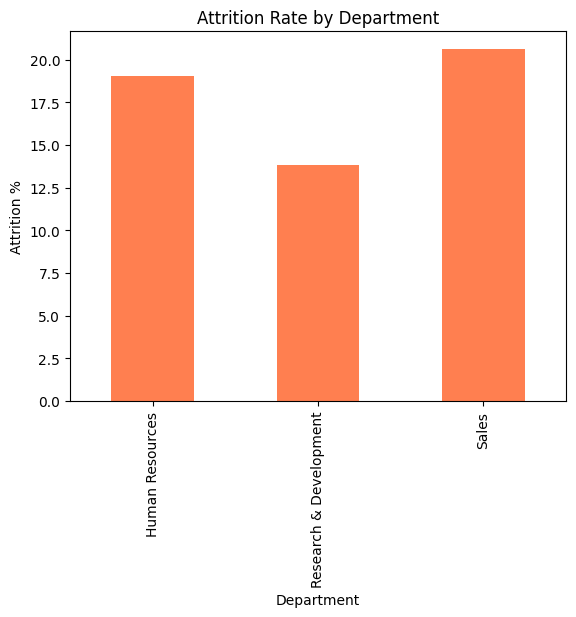

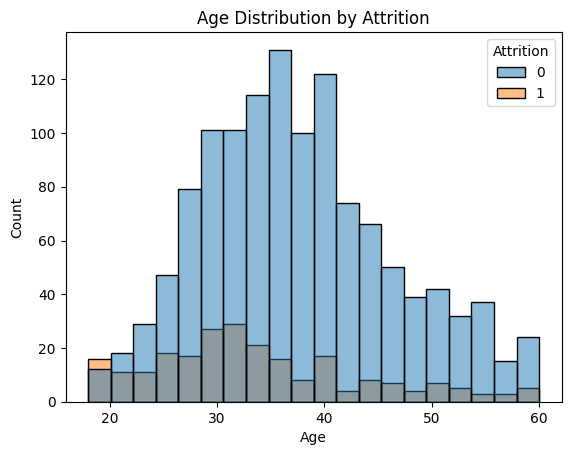

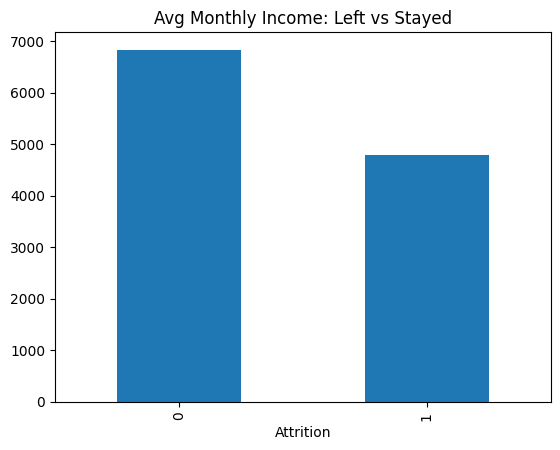

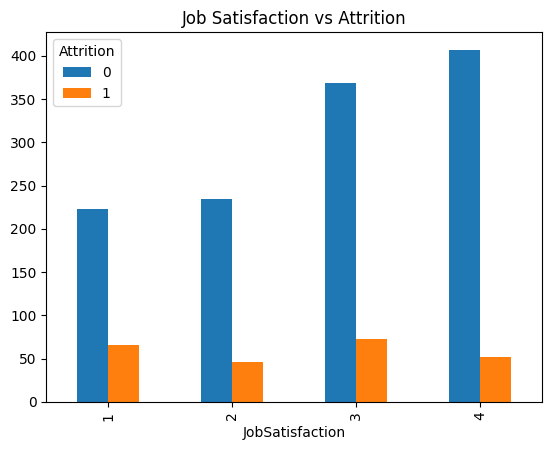

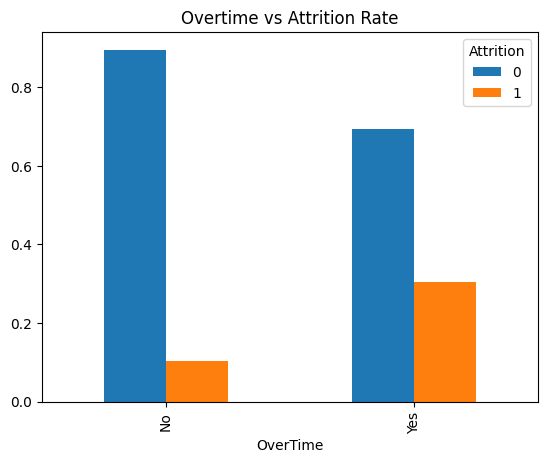

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Q1: Which department has the most attrition?
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
dept_attrition.plot(kind='bar', color='coral')
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition %')
plt.show()

# Q2: Does age affect attrition?
sns.histplot(data=df, x='Age', hue='Attrition', bins=20)
plt.title('Age Distribution by Attrition')
plt.show()

# Q3: Does salary (MonthlyIncome) matter?
df.groupby('Attrition')['MonthlyIncome'].mean().plot(kind='bar')
plt.title('Avg Monthly Income: Left vs Stayed')
plt.show()

# Q4: Does job satisfaction matter?
pd.crosstab(df['JobSatisfaction'], df['Attrition']).plot(kind='bar')
plt.title('Job Satisfaction vs Attrition')
plt.show()

# Q5: Does overtime matter?
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index').plot(kind='bar')
plt.title('Overtime vs Attrition Rate')
plt.show()

In [9]:
import sqlite3

conn = sqlite3.connect('hr_database.db')
df.to_sql('employees', conn, if_exists='replace', index=False)
print("Data loaded successfully")

Data loaded successfully


In [10]:
# 1. Overall attrition rate
query = """
SELECT
    COUNT(*) AS total_employees,
    SUM(Attrition) AS employees_left,
    ROUND(SUM(Attrition) * 100.0 / COUNT(*), 2) AS attrition_rate
FROM employees
"""

result = pd.read_sql_query(query, conn)
print(result)

   total_employees  employees_left  attrition_rate
0             1470             237           16.12


In [11]:
# 2. Attrition by department

query = """
SELECT
    Department,
    COUNT(*) AS total,
    SUM(Attrition) AS left_count,
    ROUND(SUM(Attrition) * 100.0 / COUNT(*), 2) AS attrition_pct
FROM employees
GROUP BY Department
ORDER BY attrition_pct DESC;
"""

result = pd.read_sql_query(query, conn)
print(result)

               Department  total  left_count  attrition_pct
0                   Sales    446          92          20.63
1         Human Resources     63          12          19.05
2  Research & Development    961         133          13.84


In [12]:
# 3. Do low earners leave more?
query = """
SELECT
    CASE
        WHEN MonthlyIncome < 3000 THEN 'Low'
        WHEN MonthlyIncome BETWEEN 3000 AND 7000 THEN 'Mid'
        ELSE 'High'
    END AS salary_band,
    ROUND(AVG(Attrition) * 100, 2) AS attrition_rate
FROM employees
GROUP BY salary_band;
"""

result = pd.read_sql_query(query, conn)
print(result)

  salary_band  attrition_rate
0        High           10.80
1         Low           28.61
2         Mid           12.03


In [13]:
# 4. Overtime impact
query = """
SELECT
    OverTime,
    COUNT(*) AS total,
    ROUND(AVG(Attrition) * 100, 2) AS attrition_rate
FROM employees
GROUP BY OverTime;
"""

result = pd.read_sql_query(query, conn)
print(result)

  OverTime  total  attrition_rate
0       No   1054           10.44
1      Yes    416           30.53


In [14]:
# 5. Years at company vs attrition
query = """
SELECT
    YearsAtCompany,
    ROUND(AVG(Attrition) * 100, 2) AS attrition_rate
FROM employees
GROUP BY YearsAtCompany
ORDER BY YearsAtCompany;
"""

result = pd.read_sql_query(query, conn)
print(result)

    YearsAtCompany  attrition_rate
0                0           36.36
1                1           34.50
2                2           21.26
3                3           15.63
4                4           17.27
5                5           10.71
6                6           11.84
7                7           12.22
8                8           11.25
9                9            9.76
10              10           15.00
11              11            6.25
12              12            0.00
13              13            8.33
14              14           11.11
15              15            5.00
16              16            8.33
17              17           11.11
18              18            7.69
19              19            9.09
20              20            3.70
21              21            7.14
22              22            6.67
23              23           50.00
24              24           16.67
25              25            0.00
26              26            0.00
27              27  

In [15]:
df.to_csv('hr_cleaned.csv', index=False)

In [16]:
from google.colab import files
files.download('hr_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>